In [17]:
import jax
from jax import random, vmap, jit, numpy as jnp
import matplotlib.pyplot as plt



def integrate_sde(x0, a, b, t, w):
    dt = jnp.diff(t)
    dw = jnp.diff(w)
    inputs = (t[:-1], dt, dw)
    def step(x_prev, input_slice):
        tn, dtn, dwn = input_slice
        x_next = x_prev + a(tn, x_prev) * dtn + b(tn, x_prev) * dwn
        return x_next, x_next
    _, x_history = jax.lax.scan(step, x0, inputs)
    return jnp.concatenate([jnp.atleast_1d(x0), x_history])


def get_w(key, t, M=1):
    dt = jnp.diff(t)
    dw = random.normal(key, shape=(M, len(dt))) * jnp.sqrt(dt)
    return jnp.concatenate([jnp.zeros((M, 1)), jnp.cumsum(dw, axis=1)], axis=1) # Ensure dw starts at 0

        
def get_t(T, N):
    return jnp.linspace(0, T, N + 1)


def get_s(s0, r, σ, t, w):
    return s0 * jnp.exp((r - 0.5 * σ**2) * t + σ * w)


def payoff(s, K, T, r, t):
    return jnp.exp(-r * (T - t)) * jnp.maximum(s - K, 0)


r = 1.5
σ = 0.4
T = 1.0
K = 0.5
a = lambda t, s: r * s
b = lambda t, s: σ * s

## Visualization

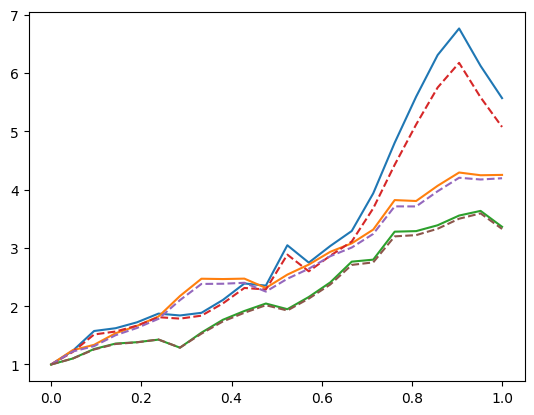

In [18]:
N = 21
M = 3
s0 = 1.0

# Set up simulation code with fixed discretization
t = get_t(T, N)
W = get_w(random.PRNGKey(0), t, M)
s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t, w))
s_num_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t, w))

# Simulate paths
s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
s_num = vmap(s_num_fcn, (None, 0))(s0, W)

# Plot results
plt.plot(t, s_tru.T.reshape(N+1, -1))
plt.plot(t, s_num.T.reshape(N+1, -1), '--')
plt.show()

## Option Pricing:
Fixed grid size, fixed samples size, different starting values $s$ and times $t$ until maturity. Given a path $S_0=s$, one can generate samples by using
$$
    f(s, t) = E[e^{-r(T-t)} \max(K-S_T, 0) | S_t=s] = E[e^{-r(T-t)}\max(K-S_{T-t},0)| S_0 = s]
$$
since $a$ and $b$ are both independent of $t$. Rewriting in reverse time $\tau=T-t$, we get
$$
    f(s, T-\tau) = E[e^{-r\tau}\max(K-S_\tau, 0) | S_0=s]
$$


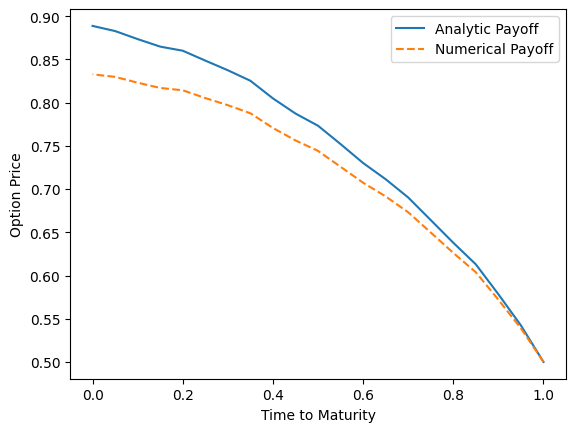

In [19]:
N = 20
M = 400
s0 = 1.0

# Set up simulation code with fixed discretization
t = get_t(T, N)
W = get_w(random.PRNGKey(0), t, M)

def f_fcn(s, τ):
    return (jnp.exp(-r * τ) * jnp.maximum(s - K, 0.)).mean(axis=0)

# Simulate paths
f_tru = lambda s0: f_fcn(vmap(s_tru_fcn, (None, 0))(s0, W), t)
f_num = lambda s0: f_fcn(vmap(s_num_fcn, (None, 0))(s0, W), t)

# 
plt.plot(T-t, f_tru(s0), label="Analytic Payoff")
plt.plot(T-t, f_num(s0), '--', label="Numerical Payoff")
plt.xlabel("Time to Maturity")
plt.ylabel("Option Price")
plt.legend()

## Option price as function of stock price, fixed time to maturity

Text(0, 0.5, 'Option Price / Strike Price')

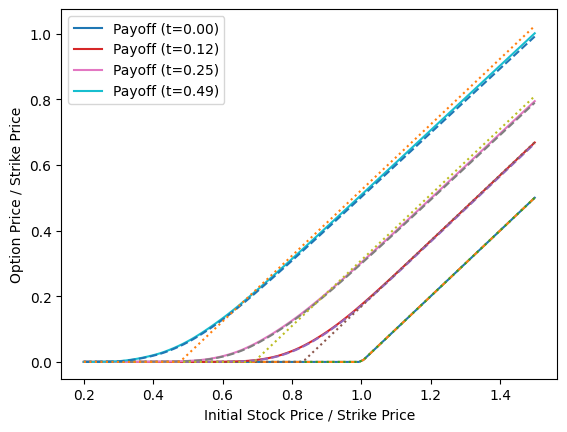

In [20]:
N_S = 101
N = 81
M = 400


s0_vec = jnp.linspace(0.2 * K, 1.5 * K, N_S)


# Set up simulation code with fixed discretization
t = get_t(T, N)
W = get_w(random.PRNGKey(0), t, M)

def f_fcn(s, τ):
    return (jnp.exp(-r * τ) * jnp.maximum(s - K, 0.)).mean(axis=0)

# Simulate paths
f_tru = vmap(lambda s0: f_fcn(vmap(s_tru_fcn, (None, 0))(s0, W), t))(s0_vec)
f_num = vmap(lambda s0: f_fcn(vmap(s_num_fcn, (None, 0))(s0, W), t))(s0_vec)
f_asy = vmap(lambda s0: jnp.maximum(s0 - K*jnp.exp(-r * t), 0.))(s0_vec)

for idx in [0, N//8, N//4, N//2]:
    plt.plot(s0_vec/K, f_tru[:, idx] / K, label=f"Payoff (t={t[idx]:.2f})")
    plt.plot(s0_vec/K, f_num[:, idx] / K, '--')
    plt.plot(s0_vec/K, f_asy[:, idx] / K, ':')
# 
plt.legend()
plt.xlabel("Initial Stock Price / Strike Price")
plt.ylabel("Option Price / Strike Price")

## Error plots 



Text(0, 0.5, 'Error at Maturity')

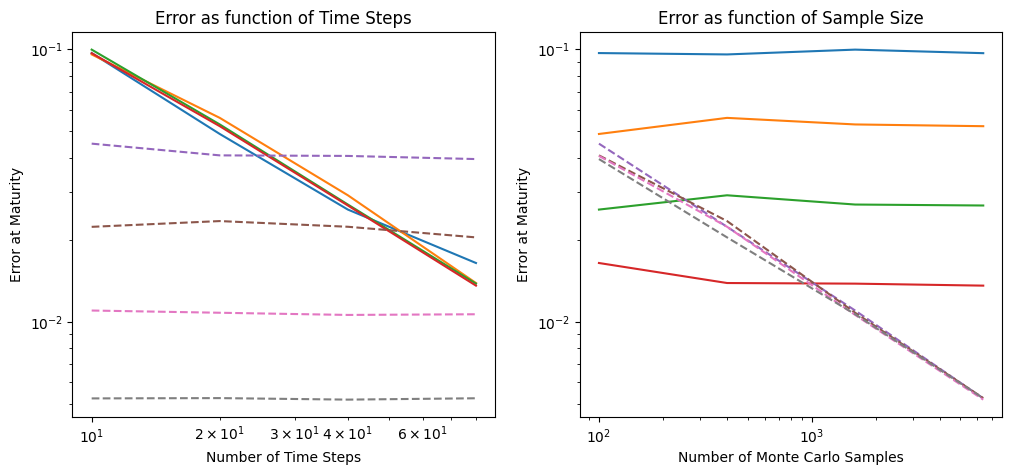

In [21]:
s0 = 1.0

def f_fcn(s, τ):
    return (jnp.exp(-r * τ) * jnp.maximum(s - K, 0.))

def error(M, N):
    # Set up simulation code with fixed discretization
    t = get_t(T, N)
    W = get_w(random.PRNGKey(0), t, M)

    # Define functions
    s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t, w))
    s_num_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t, w))

    # Simulate paths
    s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
    s_num = vmap(s_num_fcn, (None, 0))(s0, W)
    
    f_tru = f_fcn(s_tru, t)
    f_num = f_fcn(s_num, t)

    # Discretization error vs statistical error
    err_disc = jnp.abs(f_tru.mean(axis=0) - f_num.mean(axis=0))
    err_stat = jnp.std(f_tru, axis=0)/jnp.sqrt(M)
    return err_disc[-1], err_stat[-1]


M_list = jnp.array([100, 400, 1600, 6400])
N_list = jnp.array([10, 20, 40, 80])
E_disc = jnp.zeros((len(M_list), len(N_list)))
E_stat = jnp.zeros((len(M_list), len(N_list)))

for i, M in enumerate(M_list):
    for j, N in enumerate(N_list):
        err_disc, err_stat = error(M, N)
        E_disc = E_disc.at[i, j].set(err_disc)
        E_stat = E_stat.at[i, j].set(err_stat)


plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.title("Error as function of Time Steps")
plt.loglog(N_list, E_disc.T, label="Discretization Error")
plt.loglog(N_list, E_stat.T, '--', label="Statistical Error")
plt.xlabel("Number of Time Steps")
plt.ylabel("Error at Maturity")
#plt.legend()

plt.subplot(122)
plt.title("Error as function of Sample Size")
plt.loglog(M_list, E_disc, label="Discretization Error")
plt.loglog(M_list, E_stat, '--', label="Statistical Error")
plt.xlabel("Number of Monte Carlo Samples")
plt.ylabel("Error at Maturity")
#plt.legend()
        

## Variance reduction Techniques

### Optimizing samples vs Discretization.
Computing expectations of SDE solutions with $N$ discretization points and $M$ realizations typically results in a cost $MN$, and error $A/\sqrt{M} + B/N$. Minimizing error at fixed cost results in $M\propto N^2$ i.e. halving the step size does the same to the error as quadrupling the number of realizations.

In [22]:
s0 = 1.0

def error(M, N):
    # Set up simulation code with fixed discretization
    t = get_t(T, N)
    W = get_w(random.PRNGKey(0), t, M)

    # Define functions
    s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t, w))
    s_num_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t, w))

    # Simulate paths
    s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
    s_num = vmap(s_num_fcn, (None, 0))(s0, W)
    
    f_tru = f_fcn(s_tru, t)
    f_num = f_fcn(s_num, t)

    # Discretization error vs statistical error
    err_disc = jnp.abs(f_tru.mean(axis=0) - f_num.mean(axis=0))
    err_stat = jnp.std(f_tru, axis=0)/jnp.sqrt(M)
    return err_disc[-1], err_stat[-1]


M_list = jnp.array([32, 64, 128, 256])
N_list = jnp.array([96, 48,  24, 12])

for i, (M, N) in enumerate(zip(M_list, N_list)):
    err_disc, err_stat = error(M, N)
    print(f"M={M}, N={N}, err_disc={err_disc:.4e}, err_stat={err_stat:.4e}, err_tot={err_disc + err_stat:.4e}")

M=32, N=96, err_disc=1.0036e-02, err_stat=6.4888e-02, err_tot=7.4924e-02
M=64, N=48, err_disc=2.2223e-02, err_stat=5.1210e-02, err_tot=7.3433e-02
M=128, N=24, err_disc=4.3341e-02, err_stat=3.8179e-02, err_tot=8.1520e-02
M=256, N=12, err_disc=8.0496e-02, err_stat=2.6588e-02, err_tot=1.0708e-01


### Antithetic Variables

Consider a monte carlo estimate $\frac{1}{N}\sum_{n=1}^N x_n$ with identical in distribution and variance $\sigma^2$ but not necessarily independent variables $x_n$. The variance is
$$
\mathrm{Var}\left(\frac{1}{N}\sum_{n=1}^N x_n\right) = \frac{1}{N^2}\sum_{n=1}^N\sum_{m=1}^N\mathrm{Cov}\left(x_n, x_m\right) = \frac{1}{N}\sigma^2 +2\frac{1}{N^2}\sum_{n=1}^N \sum_{m=n+1}^N \mathrm{Cov}(x_m,x_n)
$$
To decrease variance, we want the covariances to be negative (promotes an even spread over the space). In the simplest case, we sample $x_n$ in pairs, such that $\mathrm{Cov}(x_n,x_m)=-\rho\sigma^2$ if $n=2k$ and $m=2k+1$,and zero otherwise, where $\rho>0$ is some correlation amount. The sum reduces to
$$
\mathrm{Var}\left(\frac{1}{N}\sum_{n=1}^N x_n\right) = \frac{1}{N}\sigma^2 - 2\frac{N/2}{N^2}\rho\sigma^2 = (1-\rho)\frac{1}{N}\sigma^2
$$
In this example, we can reduce variance to zero by choosing $\rho=1$, which is not possible in practice. One usually samples with Antithetic variables by including negative copies of the Browninan motion. which are identical in distribution to the original, but negatively correlated.


Suppose we wish to find $\mathbb{E}[g(S_T)]$. Then, denote $S_T(W(\omega))$ the solution for $S$ that one obtains at time $T$ with a particular instance $W(\omega)\colon [0,T]\to\mathbb{R}$ of brownian motion. With this notation, antithetic variates-based variance reduction looks like the following:
$$
  \frac{1}{2N}\sum_{n=1}^N g(S_T(W_n)) + g(S_T(-W_n)).
$$
In the special case when $g(x)=x$, the covariance has an analytic expression:
$$
 \mathrm{Cov}(S_T(W_n), S_T(-W_n)) = \mathbb{E}[S_0e^{(r-\sigma^2/2)T+\sigma W_T}S_0e^{(r-\sigma^2/2)T-\sigma W_T}] - S_0^2e^{2rT} = -(1 - e^{-T\sigma^2})S_0^2e^{2rT},
$$
which is exactly the negative variance of GBM, i.e. $\rho=-1$. This means that when $S_T$ is large, so that $\max(S_T-K,0)=S_T-K$, the variance for option pricing estimates is canceled almost perfectly by antithetic variates.


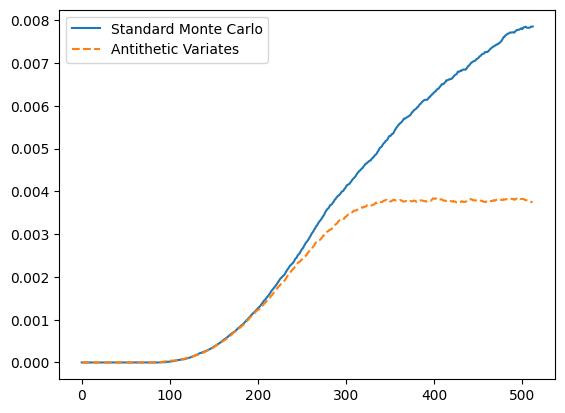

In [23]:
key = random.PRNGKey(0)

# Fixed simulation parameters
N = 256*2
M_sim = 100
M_rep = 1000
M_tot = M_sim * M_rep

s0 = 0.2
t = get_t(T, N)
s_num_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t, w))
s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t, w))

# Analytic approach
key, subkey = random.split(key)
M_ref = 10000 
W = get_w(subkey, t, M_ref)
s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
f_tru = f_fcn(s_tru, t).mean(axis=0)

# Standard Monte Carlo
key, subkey = random.split(key)
W = get_w(subkey, t, M_tot)
s_num = vmap(s_num_fcn, (None, 0))(s0, W)
f_num = f_fcn(s_num, t).reshape(M_rep, M_sim, N+1).mean(axis=1)
err_num = jnp.mean((f_num-f_tru[None, :])**2, axis=0)**0.5

# Antithetic Variates
key, subkey = random.split(key)
W_half = get_w(subkey, t, M_tot//2)
W = jnp.zeros((M_tot, N+1))
W = W.at[0::2, :].set(W_half)
W = W.at[1::2, :].set(-W_half)
s_ant = vmap(s_num_fcn, (None, 0))(s0, W)
f_ant = f_fcn(s_ant, t).reshape(M_rep, M_sim, N+1).mean(axis=1)
err_ant = jnp.mean((f_ant-f_tru[None, :])**2, axis=0)**0.5


plt.plot(err_num, label="Standard Monte Carlo")
plt.plot(err_ant, '--', label="Antithetic Variates")
#plt.plot(f_tru, ':', label="Analytic Payoff")
plt.legend()

## Covariates

The basic idea of covariates is to write the expectation as
$$
\mathbb{E}[X] = \mathbb{E}[\tilde X] + \mathbb{E}[X - \tilde X],
$$
where $\tilde X$ and $\mathbb{E}[\tilde X]$ are cheaply computable, and $\tilde X$ is a decent approximation of $X$. In the lecture notes, we see an example for rainbow option pricing using the geometric mean as a covariate for the arithmetic mean. Then, we estimate the mean of $X-\tilde X$ by monte-carlo, which results in the variance
$$
\mathrm{Var}(\mathbb{E}[\tilde X] + \frac{1}{N}\sum_{n=1}(X_n-\tilde X_n)) = \frac{1}{N}\mathrm{Var}(X_1-\tilde X_1).
$$
If $\tilde X_1$ is a good predictor of $X_1$, we expect that $\mathrm{Var}(X_1-\tilde X_1) \leq \mathrm{Var}(X_1)$, which results in a reduction in cost compared to the standard approach, provided that sampling $\tilde X_1$ and computing its mean is comparatively cheap compared to sampling $X_1$.


## Two-Level Monte Carlo

A special case of the method of covariates for SDE is to use a coarse discretization of the SDE instead. So, suppose $X_t^N = e^{-r t}\max(S_t^{N}-K,0)$ is the discounted option payoff for a single instance of a stock $S_t$ with $N$ discretisation points. Then, $X_t^N$ and $X_t^{4N}$ are highly correlated, but $X_t^{4N}$ is four times as expensive to compute. 

Let's generate $3M$ copies of $X_t^N$, and then, from the same samples of brownian motion, generate $M$ more correlated copies of $X_t^N$ and of $X_t^{4N}$. The total cost of these computations is $4N*M$ for the expensive solutions, and $N*4M$ for the cheap ones. The cost is the same as if we generated $2M$ copies of $X_t^{4N}$, but effectively we now have $5M$ copies of $X_t$ -- $4M$ from the bad approximation, and $M$ from the good ones. 

### Error of Method 1:

$3M$ copies of $X_t^N$ and then $M$ correlated copies of $X_t^N$ and $X_t^{4N}$ (based on the same browninan motion). The mean square error, assuming $X_t^{4N}$ itself has zero error (simplification):
$$
\mathbb{E}\left[\left(\left\{\frac{1}{3M}\sum_{n=M+1}^{3M} X_{t,n}^{N} + \frac{1}{M}\sum_{t,n}^N X_{t,n}^{4N}-X_{t,n}^N\right\} - \mathbb{E}[X_{t}^{\infty}]\right)^2\right]
$$

After adding and subtracting $\mathbb{E}[X_t^N]$ and adding and subtracting $\mathbb{E}[X_t^{4N}]$, we get, since $X_{t,M+n}^{N}$ are independently sampled from $X_{t,m}^{4N}$ and $X_{t,m}^{N}$ for $m<M$,
$$
\frac{1}{3M}\mathrm{Var}(X_{t,0}^N) + \frac{1}{M}\mathrm{Var}(X_{t,0}^N-X_{t,0}^{4N}) + \mathbb{E}[X_{t,0}^{4N}-X_{t,0}^{\infty}]^2
$$
Using that weak error is $\mathcal{O}(\Delta t)$ and strong error is $\mathcal{O}(\sqrt{\Delta t})$, we get
$$
    C_1\frac{1}{3M} + C_2\frac{1}{M}\frac{1}{N} + C_3\frac{1}{(4N)^2}
$$

### Error of Method 2:

$2M$ copies of $X_t^{4N}$ gives an error of (roughly the same constants $C_1$ and $C_2$)
$$
    C_1\frac{1}{2M} + C_3\frac{1}{(4N)^2}
$$

Notably, the method of control variates (Option 1) has the effect of reducing the statistical error, since one can make much more copies of the cheap SDE solution at a coarse discretization level. On the other hand, it adds a certain correlation error on the order of $C_2\frac{1}{MN}$, which must be small.

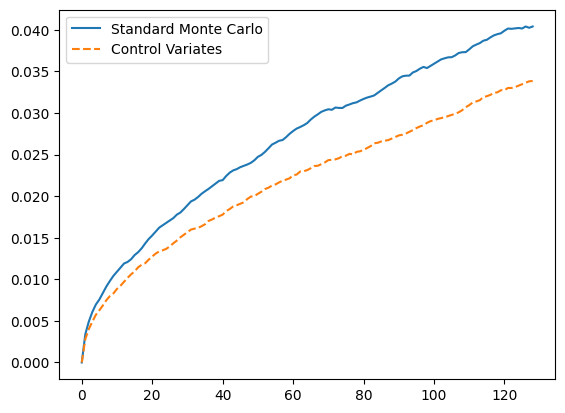

In [35]:
key = random.PRNGKey(0)
s0 = 1.0

# Fixed simulation parameters
N_bad = 128
N_god = N_bad * 4

M_sim = 50
M_rep = 1000

t_god = get_t(T, N_god)
t_bad = get_t(T, N_bad)

# Reference solution
s_num_god_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_god, w)[::4]) # Subsample to coarse grid
s_num_bad_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_bad, w))
s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t_bad, w))

# Analytic solution along coarse grid
key, subkey = random.split(key)
M_ref = 10000 
t = get_t(T, N_bad)
W = get_w(subkey, t, M_ref)
s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
f_tru = f_fcn(s_tru, t_bad).mean(axis=0)

# Standard Monte Carlo along fine grid, 2M samples to match total cost of control variates
key, subkey = random.split(key)
W = get_w(subkey, t_god, 2 * M_sim * M_rep)
s_num = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num = f_fcn(s_num, t_bad).reshape(M_rep, 2 * M_sim, N_bad+1).mean(axis=1)
err_num = jnp.mean((f_num-f_tru[None, :])**2, axis=0)**0.5 


# Control Variates
key, subkey_coarse, subkey_fine = random.split(key, 3)

# Coarse solution, 3M samples
W = get_w(subkey_coarse, t_bad, 3 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W)
f_num_coarse = f_fcn(s_num_coarse, t_bad).reshape(M_rep, 3 * M_sim, N_bad+1).mean(axis=1)

# Fine correction, M samples of both fine and coarse solutions
W = get_w(subkey_fine, t_god, 1 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W[:, ::4]) # Subsample to coarse grid
s_num_fine = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num_diff = (f_fcn(s_num_fine, t_bad)-f_fcn(s_num_coarse, t_bad)).reshape(M_rep, M_sim, N_bad+1).mean(axis=1)

f_cv = f_num_coarse + f_num_diff
err_cv = jnp.mean((f_cv-f_tru[None, :])**2, axis=0)**0.5

plt.plot(err_num, label="Standard Monte Carlo")
plt.plot(err_cv, '--', label="Control Variates")
#plt.plot(f_tru, ':', label="Analytic Payoff")
plt.legend()

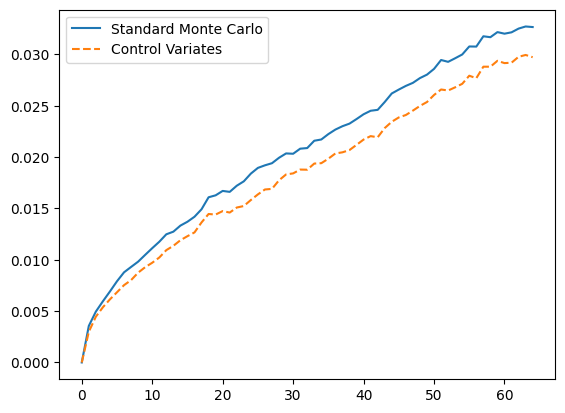

In [39]:
key = random.PRNGKey(0)
s0 = 1.0

# Fixed simulation parameters
N_bad = 64
N_god = N_bad * 2

M_sim = 50
M_rep = 1000

t_god = get_t(T, N_god)
t_bad = get_t(T, N_bad)

# Reference solution
s_num_god_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_god, w)[::2]) # Subsample to coarse grid
s_num_bad_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_bad, w))
s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t_bad, w))

# Analytic solution along coarse grid
key, subkey = random.split(key)
M_ref = 10000 
t = get_t(T, N_bad)
W = get_w(subkey, t, M_ref)
s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
f_tru = f_fcn(s_tru, t_bad).mean(axis=0)

# Standard Monte Carlo along fine grid, 2M samples to match total cost of control variates
key, subkey = random.split(key)
W = get_w(subkey, t_god, 4 * M_sim * M_rep)
s_num = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num = f_fcn(s_num, t_bad).reshape(M_rep, 4 * M_sim, N_bad+1).mean(axis=1)
err_num = jnp.mean((f_num-f_tru[None, :])**2, axis=0)**0.5 


# Control Variates
key, subkey_coarse, subkey_fine = random.split(key, 3)

# Coarse solution, 3M samples
W = get_w(subkey_coarse, t_bad, 5 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W)
f_num_coarse = f_fcn(s_num_coarse, t_bad).reshape(M_rep, 5 * M_sim, N_bad+1).mean(axis=1)

# Fine correction, M samples of both fine and coarse solutions
W = get_w(subkey_fine, t_god, 1 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W[:, ::2]) # Subsample to coarse grid
s_num_fine = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num_diff = (f_fcn(s_num_fine, t_bad)-f_fcn(s_num_coarse, t_bad)).reshape(M_rep, M_sim, N_bad+1).mean(axis=1)

f_cv = f_num_coarse + f_num_diff
err_cv = jnp.mean((f_cv-f_tru[None, :])**2, axis=0)**0.5

plt.plot(err_num, label="Standard Monte Carlo")
plt.plot(err_cv, '--', label="Control Variates")
#plt.plot(f_tru, ':', label="Analytic Payoff")
plt.legend()

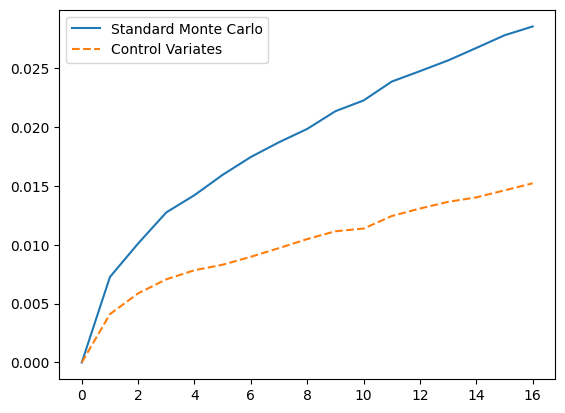

In [42]:
key = random.PRNGKey(0)
s0 = 1.0

# Fixed simulation parameters
N_bad = 16
N_god = N_bad * 8

M_sim = 100
M_rep = 1000

t_god = get_t(T, N_god)
t_bad = get_t(T, N_bad)

# Reference solution
s_num_god_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_god, w)[::8]) # Subsample to coarse grid
s_num_bad_fcn = jit(lambda s0, w: integrate_sde(s0, a, b, t_bad, w))
s_tru_fcn = jit(lambda s0, w: get_s(s0, r, σ, t_bad, w))

# Analytic solution along coarse grid
key, subkey = random.split(key)
M_ref = 10000 
t = get_t(T, N_bad)
W = get_w(subkey, t, M_ref)
s_tru = vmap(s_tru_fcn, (None, 0))(s0, W)
f_tru = f_fcn(s_tru, t_bad).mean(axis=0)

# Standard Monte Carlo along fine grid, 2M samples to match total cost of control variates
key, subkey = random.split(key)
W = get_w(subkey, t_god, 2 * M_sim * M_rep)
s_num = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num = f_fcn(s_num, t_bad).reshape(M_rep, 2 * M_sim, N_bad+1).mean(axis=1)
err_num = jnp.mean((f_num-f_tru[None, :])**2, axis=0)**0.5 


# Control Variates
key, subkey_coarse, subkey_fine = random.split(key, 3)

# Coarse solution, 3M samples
W = get_w(subkey_coarse, t_bad, 7 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W)
f_num_coarse = f_fcn(s_num_coarse, t_bad).reshape(M_rep, 7 * M_sim, N_bad+1).mean(axis=1)

# Fine correction, M samples of both fine and coarse solutions
W = get_w(subkey_fine, t_god, 1 * M_sim * M_rep)
s_num_coarse = vmap(s_num_bad_fcn, (None, 0))(s0, W[:, ::8]) # Subsample to coarse grid
s_num_fine = vmap(s_num_god_fcn, (None, 0))(s0, W)
f_num_diff = (f_fcn(s_num_fine, t_bad)-f_fcn(s_num_coarse, t_bad)).reshape(M_rep, M_sim, N_bad+1).mean(axis=1)

f_cv = f_num_coarse + f_num_diff
err_cv = jnp.mean((f_cv-f_tru[None, :])**2, axis=0)**0.5

plt.plot(err_num, label="Standard Monte Carlo")
plt.plot(err_cv, '--', label="Control Variates")
#plt.plot(f_tru, ':', label="Analytic Payoff")
plt.legend()

## Advanced: Multilevel Monte Carlo

In multilevel Monte Carlo schemes, one uses a telescoping sum of a hierarchy of discretisation levels:
$$
    \mathbb{E}[X_t^{4^K}] = \mathbb{E}[X_t^{1}] + \sum_{k=1}^K \mathbb{E}[X_t^{4^k} - X_t^{4^{k-1}}]
$$
And at each level $k$, we use a different number of samples $M_k$, roughly proportional to $2^{K-k}$.